# Tarea Semanal 4
## Autor: Pedro Guzman


### Consigna 
Haremos el siguiente experimento:

Senoidal de frecuencia $f_0 = k_0 * f_S/N = k_0 . \Delta_f$ potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea $k_0 = \{ N/4, N/4 + 0.25, N/4 + 0.5 \}$. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $\Delta_f$. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?

### Bonus:
💎 Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $\Delta_f$ de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.
 



### Solucion Propuesta

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal as sp
import time
from scipy.fft import fft, ifft
import scipy.signal as signal

#Funcion del generador de se;ales
def  mi_funcion ( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 50, type_s = 'sine', duty = 0.5, vmed=5e-3, vsigma=0.5e-3) :
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    if   type_s == 'sine' :
        xx = vmax*np.sin(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'sawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'triangle' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph,width = 0.5)+dc
    elif type_s == 'invsawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph, width = 0)+dc
    elif type_s == 'square' :
        xx = vmax*sp.square(2*np.pi*ff*tt+ph, duty = duty)+dc
    elif type_s == 'noise' :
        xx = np.random.normal(vmed, vsigma, len(tt))+dc
    else :
        print("Tipo de funcion no existente o incorrecta")
    
    return tt, xx

def Quant(VFS, x, B) :
    
    q = VFS/(2**B)
    SQ = np.round(x/q)*q
    SQ = np.clip(SQ,a_min=-q*(2**(B-1)) , a_max=q*(2**(B-1)-1))
    print(f"Cuanto={q} para Vref={VFS} y cantidad de bits = {B}")
    return SQ

def  mi_generador_ruidoso ( Psine = 1,R = 1 ,SNRdB=10, ff = 1, ph = 0, nn = 100, fs = 50) :
    vmax=np.sqrt(Psine*2*R)
    Pnoise=Psine/(10**(SNRdB/10))
    vsigma=np.sqrt(Pnoise*R)
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    _, xx_sine = mi_funcion( vmax = vmax, dc = 0, ff = ff, ph= ph, nn = nn, fs = fs, type_s = 'sine')
    _ ,xx_noise = mi_funcion( vmed = 0, vsigma = vsigma, nn = nn, fs = fs, type_s = 'noise')
    xx= xx_sine + xx_noise
    SNR_real = 10 * np.log10(Psine / np.var(xx_noise))
    print(f"SNR real: {SNR_real:.9f} dB")
    return tt, xx, xx_sine , xx_noise

def DFT(x):
    
    N=len(x)
    n = np.arange(N)
    k=n.reshape((N,1)) #Vector fila a Vector columna
    e=np.exp(-2j*np.pi*k*n/N)
    Xk=np.dot(x,e) #Producto Punto.
    
    return Xk 

#### Inciso a

In [2]:
N=10000
fs   = 100
deltaf=fs/N
ff = fs/4
ff2 = fs/4 + deltaf/4
ff3 = fs/4 + deltaf/2



t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = 0, nn = N, fs = fs, type_s = 'sine')
t, x2 = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff2, ph = 0, nn = N, fs = fs, type_s = 'sine')
t, x3 = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff3, ph = 0, nn = N, fs = fs, type_s = 'sine')


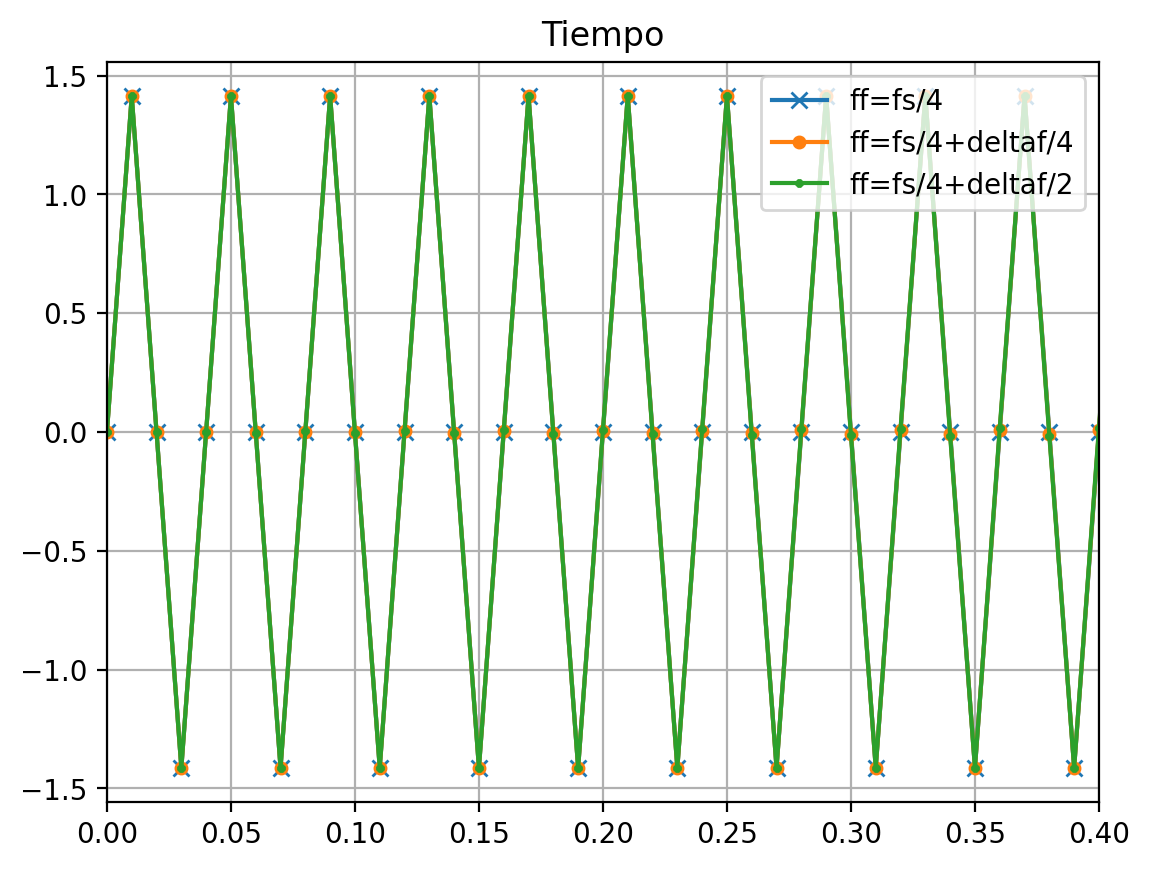

In [3]:
plt.figure(dpi=200)
plt.title("Tiempo")
plt.plot(t,x, label=  "ff=fs/4", marker= "x", markersize = 6 )
plt.plot(t,x2, label= "ff=fs/4+deltaf/4", marker= "o", markersize = 4 )
plt.plot(t,x3, label= "ff=fs/4+deltaf/2", marker= "8", markersize = 2 )
plt.xlim(0, 10/ff)
plt.grid()
plt.legend()

In [4]:
xk1= DFT(x)
xk2= DFT(x2)
xk3= DFT(x3)
freq= np.arange(start = 0, stop = fs//2, step = deltaf)

0.01


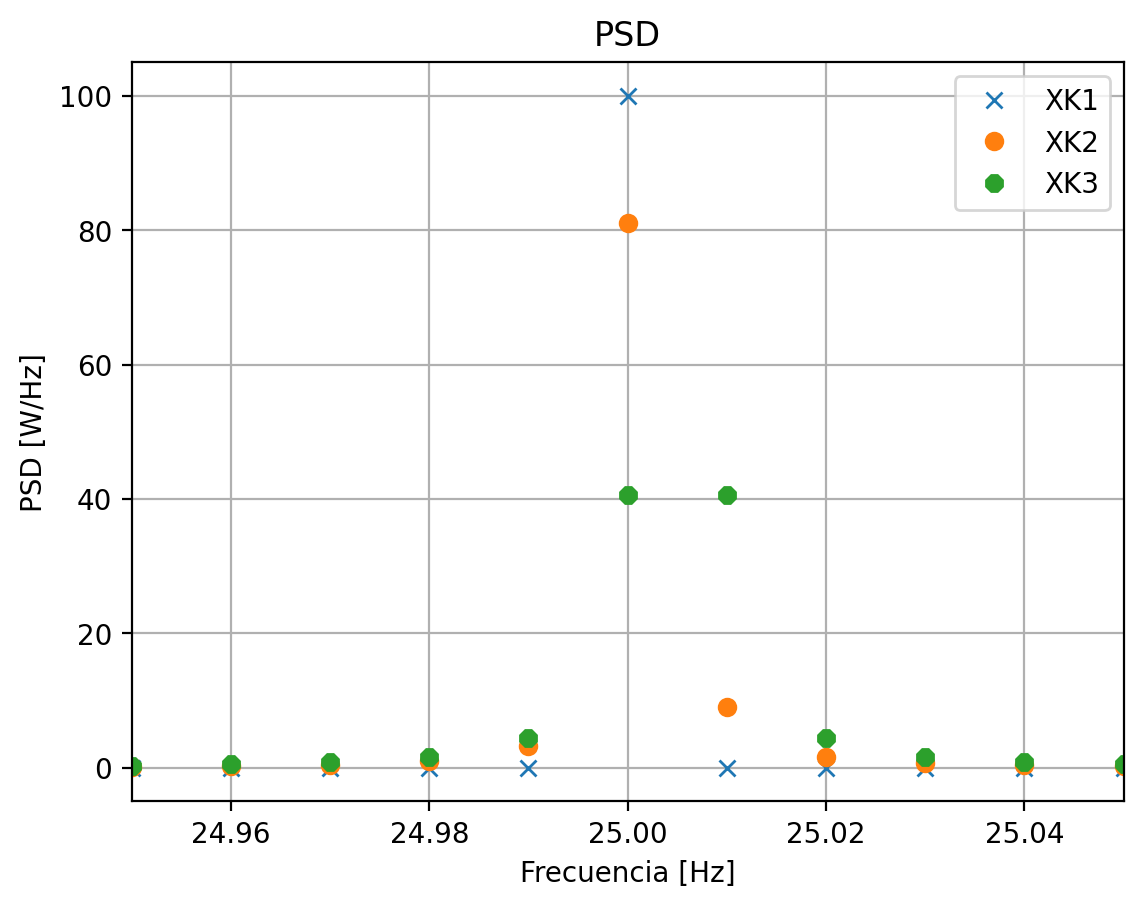

In [5]:
PSDXK1=2*np.abs(xk1[:N//2])**2/(N*fs)
PSDXK2=2*np.abs(xk2[:N//2])**2/(N*fs)
PSDXK3=2*np.abs(xk3[:N//2])**2/(N*fs)


plt.figure(dpi=200)
plt.title("PSD")
plt.plot(freq, PSDXK1,    label="XK1", marker='x', linestyle='None',markersize = 6)
plt.plot(freq, PSDXK2,    label="XK2", marker='o', linestyle='None',markersize = 6)
plt.plot(freq, PSDXK3,    label="XK3", marker='8', linestyle='None',markersize = 6)

plt.xlim(ff-5*deltaf, ff+5*deltaf)
plt.grid()
plt.ylabel("PSD [W/Hz]")
plt.xlabel("Frecuencia [Hz]")
plt.legend()
print(deltaf)

La desintonia causa que la potencia total de la señal se distribuya en los bins mas cercanos. Esto es debido a que la frecuencia de la señal al no calzar en un bin exacto de frecuencia, la potencia de la misma se distribuye en el espectro. 

La DFT/FFT calcula la transformada discreta de fourier, tiene como funcion de entrada una funcion compuesta por nuestra señal, multiplicada por un pulso de valor unitario de duracion de N*Ts, eso es en espectro de frecuencia es la convolucion de dos señales en frecuencia, la transformada de fourier de nuestra señal muestreada y la transformada de fourier del pulso, que es una Sinc.

Cuando la señal de entrada original, coincide con un bin de frecuencia de la DFT, la convolución de la Sinc deja las repeticiones de la señal sobre los 0 de la Sinc, por lo tanto no hay potencia desparramada en el espectro.

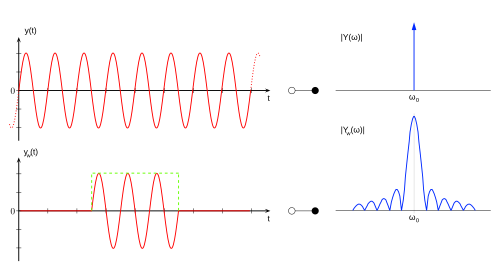

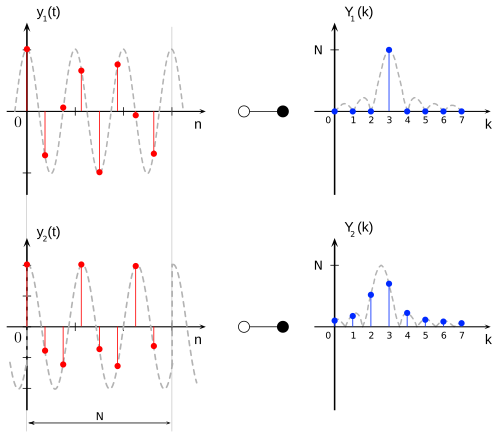

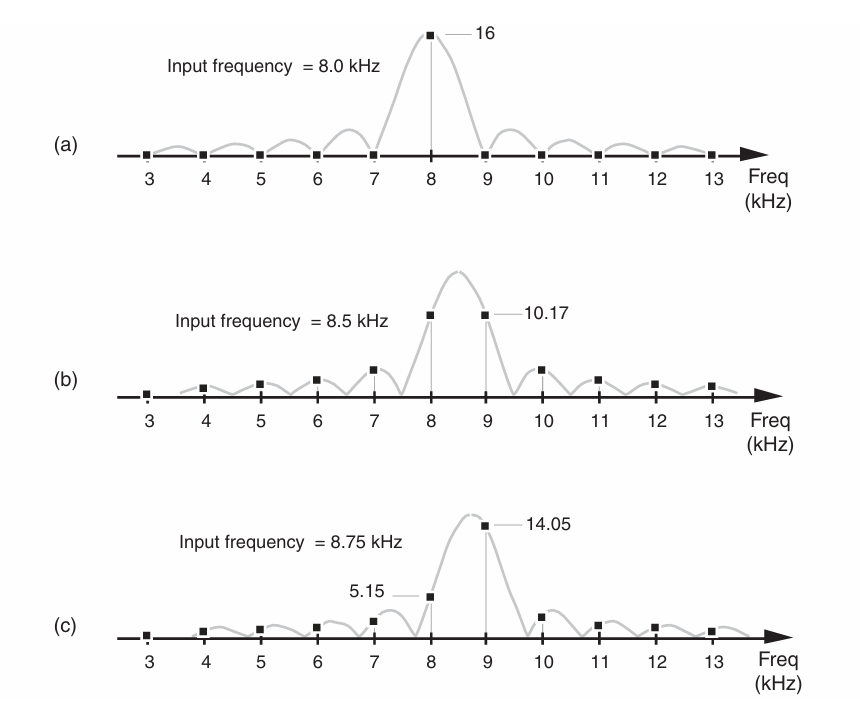

#### Inciso b

In [6]:
print(f"Potencia XK1: {np.sum(PSDXK1) * deltaf:.9f} W")  
print(f"Potencia XK2: {np.sum(PSDXK2) * deltaf:.9f} W") 
print(f"Potencia XK3: {np.sum(PSDXK3) * deltaf:.9f} W")  

Potencia XK1: 1.000000000 W
Potencia XK2: 0.999899980 W
Potencia XK3: 1.000000000 W


Se puede ver como integrando toda la PSD llegamos a la potencia unitaria de la señal original. Por lo tanto la potencia se mantiene solo que se dessparrama en el espectro

#### Bonus

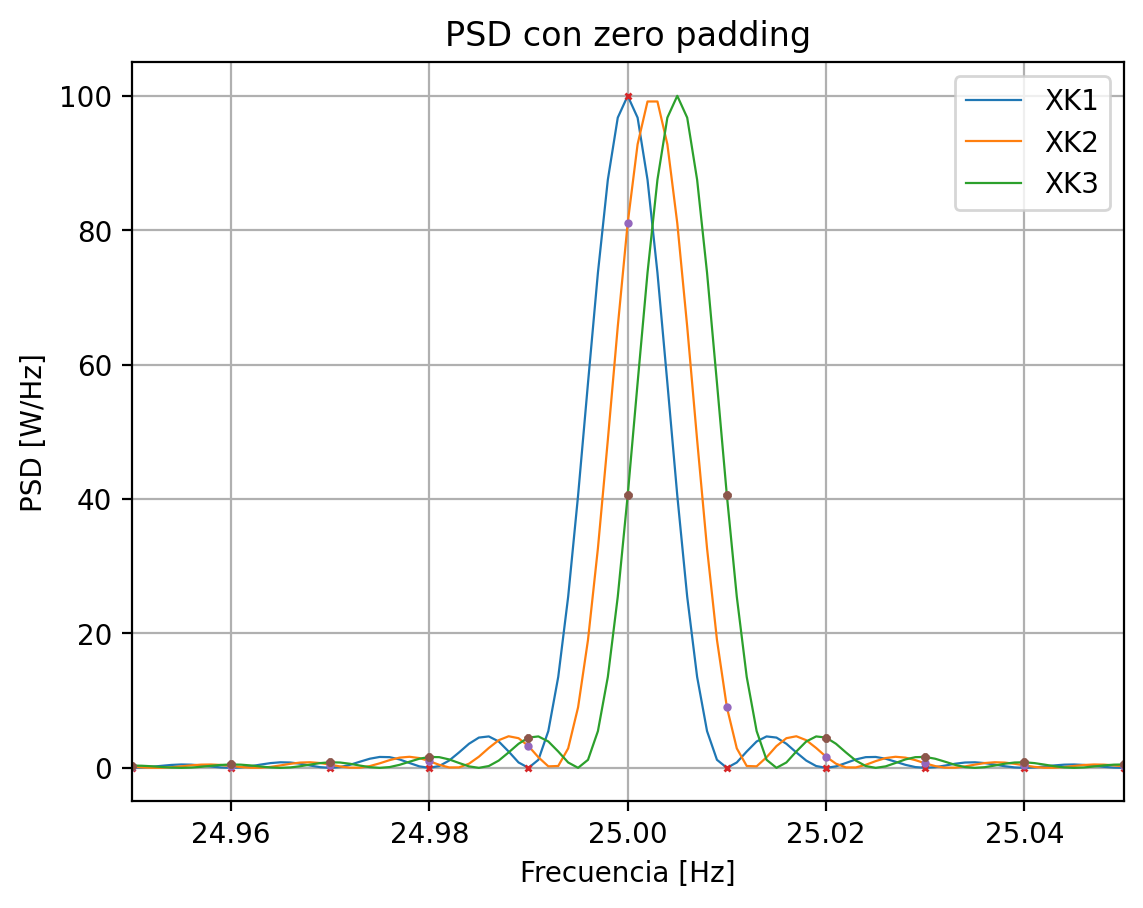

In [11]:
Nzp = N * 10 # (N original + 9*N agregados )

xk1_zp = np.fft.fft(x, n=Nzp) # Si lo calculo con mi funcion mi computadora sufre
xk2_zp = np.fft.fft(x2, n=Nzp)
xk3_zp = np.fft.fft(x3, n=Nzp)
deltaf_zp = fs/Nzp
freq_zp= np.arange(start = 0, stop = fs//2, step = deltaf_zp)

PSD1_zp = 2*np.abs(xk1_zp[:Nzp//2])**2/(N*fs)
PSD2_zp = 2*np.abs(xk2_zp[:Nzp//2])**2/(N*fs)
PSD3_zp = 2*np.abs(xk3_zp[:Nzp//2])**2/(N*fs)


plt.figure(dpi=200)
plt.title("PSD con zero padding")
plt.plot(freq_zp, PSD1_zp, label="XK1", linewidth=0.8) #Importante que sea N y no Nzp
plt.plot(freq_zp, PSD2_zp, label="XK2", linewidth=0.8) #Importante que sea N y no Nzp
plt.plot(freq_zp, PSD3_zp, label="XK3", linewidth=0.8) #Importante que sea N y no Nzp
plt.plot(freq, PSDXK1, marker='x', linestyle='None',markersize = 2)
plt.plot(freq, PSDXK2, marker='o', linestyle='None',markersize = 2)
plt.plot(freq, PSDXK3, marker='8', linestyle='None',markersize = 2)
plt.xlim(ff-5*deltaf, ff+5*deltaf)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [W/Hz]")
plt.grid()
plt.legend()

In [12]:
print(f"Potencia XK1: {np.sum(PSD1_zp) * deltaf_zp:.9f} W")  
print(f"Potencia XK2: {np.sum(PSD1_zp) * deltaf_zp:.9f} W") 
print(f"Potencia XK3: {np.sum(PSD1_zp) * deltaf_zp:.9f} W")  

Potencia XK1: 1.000000000 W
Potencia XK2: 1.000000000 W
Potencia XK3: 1.000000000 W


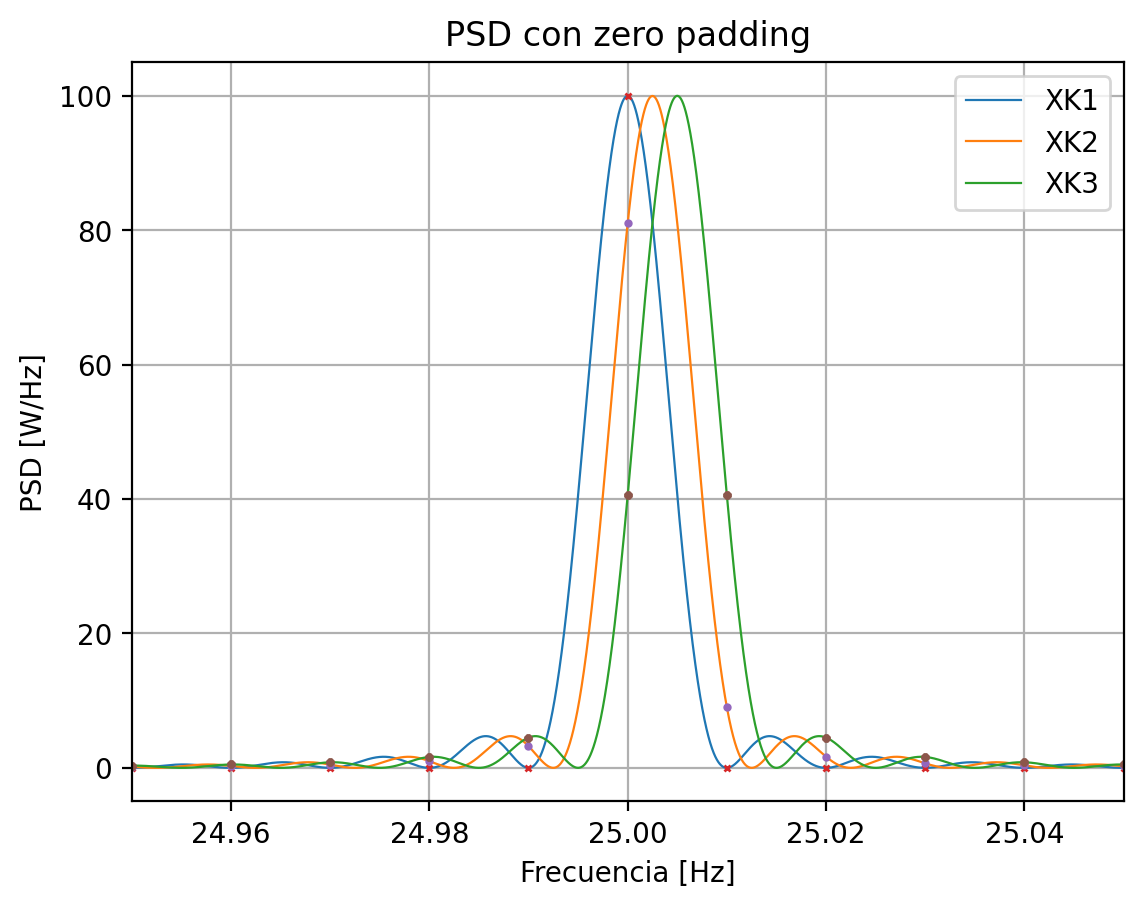

In [13]:
Nzp = N * 1000

xk1_zp = np.fft.fft(x, n=Nzp) # Si lo calculo con mi funcion mi computadora sufre
xk2_zp = np.fft.fft(x2, n=Nzp)
xk3_zp = np.fft.fft(x3, n=Nzp)
deltaf_zp = fs/Nzp
freq_zp= np.arange(start = 0, stop = fs//2, step = deltaf_zp)

PSD1_zp = 2*np.abs(xk1_zp[:Nzp//2])**2/(N*fs) #Importante que sea N y no Nzp
PSD2_zp = 2*np.abs(xk2_zp[:Nzp//2])**2/(N*fs) #Importante que sea N y no Nzp
PSD3_zp = 2*np.abs(xk3_zp[:Nzp//2])**2/(N*fs) #Importante que sea N y no Nzp

#Segun Lyons tiene que ser N y no Nzp, ver referencia capitulo

plt.figure(dpi=200)
plt.title("PSD con zero padding")
plt.plot(freq_zp, PSD1_zp, label="XK1", linewidth=0.8)
plt.plot(freq_zp, PSD2_zp, label="XK2", linewidth=0.8)
plt.plot(freq_zp, PSD3_zp, label="XK3", linewidth=0.8)
plt.plot(freq, PSDXK1, marker='x', linestyle='None',markersize = 2)
plt.plot(freq, PSDXK2, marker='o', linestyle='None',markersize = 2)
plt.plot(freq, PSDXK3, marker='8', linestyle='None',markersize = 2)
plt.xlim(ff-5*deltaf, ff+5*deltaf)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [W/Hz]")
plt.grid()
plt.legend()

In [14]:
print(f"Potencia XK1: {np.sum(PSD1_zp) * deltaf_zp:.9f} W")  
print(f"Potencia XK2: {np.sum(PSD1_zp) * deltaf_zp:.9f} W") 
print(f"Potencia XK3: {np.sum(PSD1_zp) * deltaf_zp:.9f} W")  

Potencia XK1: 1.000000000 W
Potencia XK2: 1.000000000 W
Potencia XK3: 1.000000000 W


El Zero Padding no agrega nueva información a nuestro espectro, ensencialmente lo que hace es una interpolación, NO AUMENTA LA RESOLUCIÓN DE NUESTRA FFT PARA DISTINGUIR COMPONENTES CERCANAS EN FRECUENCIA, ademas hay que tener cuidado al aplicarlo, porque al agregar ceros al final de la señal donde tenemos L muestras que no son 0, hay que tener cuidado al escalarla, se debe usar el valor L para obtener el valor de la amplitud real de la misma. Otro cuidado que hay que tener es cuando aplicamos ventaneo y Zero Padding, primero se aplica el ventaneo a la señal original y despues se aplica el Padding, si no podemos llegar a obtener resultados erroneos.

Se puede ver como con el Zero Padding podemos aproximar la DFT a una DTFT (discrete-time Fourier transform)

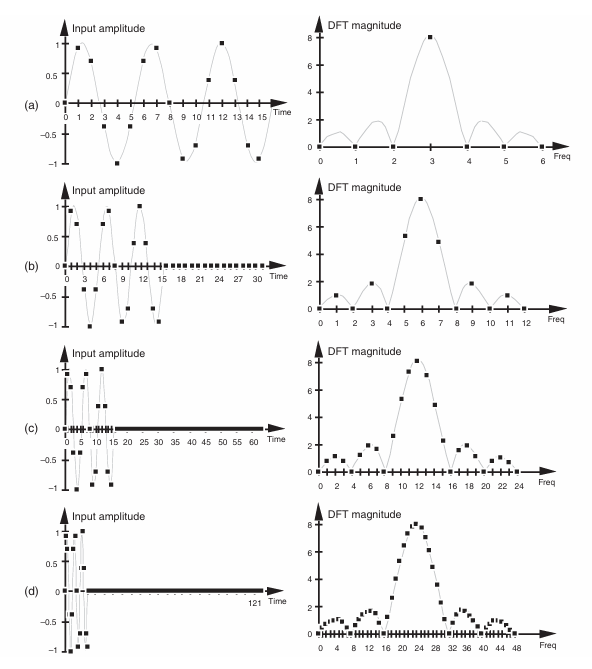